# Using the RAKE Algorithm to identify Data Science Keywords

This scraping project retrieves text from the [Wikipedia Article about Data Science](https://en.wikipedia.org/wiki/Data_science) with the aim of extracting keywords related to the field of Data Science.

To do this, the following libraries will be used:

* `requests` - to send a GET HTTP request to the corresponding Wikipedia Article URL

* `BeautifulSoup` and `lxml` - to parse the HTML data retrieved from the response

* `nlp-rake` - RAKE: a **Natural Language Processing** (NLP) Algorithm for **R**apid **A**utomatic **K**eyword **E**xtraction.

* `matplotlib` and `Wordcloud` - visualization

## Scraping the Data

In [89]:
import requests
import lxml
from bs4 import BeautifulSoup

url = "https://en.wikipedia.org/wiki/Data_science"

try:
  response = requests.get(url, headers={"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36"})
  
  response.raise_for_status()  # Check if the request was successful
  
except requests.exceptions.RequestException as e:
  print(f"An error occurred while fetching the page: {e}")

html_text = response.content.decode("utf-8")

In [90]:
print(html_text[:1000])  # first 1000 characters of the HTML content

<!DOCTYPE html>
<html class="client-nojs vector-feature-language-in-header-enabled vector-feature-language-in-main-menu-disabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limited-width-content-enabled vector-feature-custom-font-size-clientpref-1 vector-feature-appearance-pinned-clientpref-1 skin-theme-clientpref-day vector-sticky-header-enabled wp25eastereggs-enable-clientpref-1 vector-toc-available skin-theme-clientpref-thumb-standard" lang="en" dir="ltr">
<head>
<meta charset="UTF-8">
<title>Data science - Wikipedia</title>
<script>(function(){var className="client-js vector-feature-language-in-header-enabled vector-feature-language-in-main-menu-disabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feat

The article text is located within the main body, specifically within the div HTML tag with class attribute `mw-content-ltr mw-parser-output`.

In [91]:
soup = BeautifulSoup(html_text, "lxml")

content = soup.find("div", class_="mw-content-ltr mw-parser-output")

print(content.text[:1000])

Field of study to extract knowledge from data
Not to be confused with Information science or Computer science.


The existence of Comet NEOWISE (here depicted as a series of red dots) was discovered by analyzing astronomical survey data acquired by a space telescope, the Wide-field Infrared Survey Explorer.
Data science is an interdisciplinary academic field[1] that uses statistics, scientific computing, scientific methods, processing, scientific visualization, algorithms, and systems to extract or extrapolate knowledge from potentially noisy, structured, or unstructured data.[2]
Data science also integrates domain knowledge from the underlying application domain (e.g., natural sciences, information technology, and medicine).[3] Data science is multifaceted and can be described as a science, a research paradigm, a research method, a discipline, a workflow, and a profession.[4]
Data science is "a concept to unify statistics, data analysis, informatics, and their related methods" to "und

This needs to be cleaned to remove reference links, image captions, sidebars, jump links *etc.*

## Cleaning the Article Text

In [92]:
def clean_wiki_content(content_node):
    """Remove all non-article content from the Wikipedia page text."""
    selectors = [
        ".mw-jump-link",
        ".navbox",
        ".reflist",
        "sup.reference",
        ".mw-editsection",
        ".hatnote",
        ".metadata",
        ".infobox",
        ".toc",
        "#toc",
        ".sidebar",
        "mw-references-wrap mw-references-columns"
      ]
    
    for selector in selectors:
        for element in content_node.select(selector):
            element.decompose()  # Remove the element from the soup

    return content

if content:
    content = clean_wiki_content(content)
    text = content.get_text(separator=" ", strip=True)
    text = text.replace("^","") # remove remaining reference markers
    print(text) 

else:
    print("Main content not found. Using full page text instead.")
    text = soup.get_text(separator=" ", strip=True)
    print(text)

Field of study to extract knowledge from data The existence of Comet NEOWISE (here depicted as a series of red dots) was discovered by analyzing astronomical survey data acquired by a space telescope , the Wide-field Infrared Survey Explorer . Data science is an interdisciplinary academic field that uses statistics , scientific computing , scientific methods , processing, scientific visualization , algorithms , and systems to extract or extrapolate knowledge from potentially noisy, structured , or unstructured data . Data science also integrates domain knowledge from the underlying application domain (e.g., natural sciences, information technology, and medicine). Data science is multifaceted and can be described as a science, a research paradigm, a research method, a discipline, a workflow, and a profession. Data science is "a concept to unify statistics , data analysis , informatics , and their related methods " to "understand and analyze actual phenomena " with data . It uses techniq

### Applying the RAKE Algorithm

In [93]:
import matplotlib.pyplot as plt
from nlp_rake import Rake

rake = Rake(max_words=2, min_freq=3, min_chars=5) 
# parameters - max_words: maximum number of words allowed in a keyword phrase, min_freq: minimum frequency of a keyword to be included, min_chars: minimum number of characters in a keyword

results = rake.apply(text)
results

[('data scientist', 4.0),
 ('sexiest job', 4.0),
 ('21st century', 4.0),
 ('statistical learning', 4.0),
 ('big data', 4.0),
 ('data science', 3.9047619047619047),
 ('computer science', 3.9047619047619047),
 ('information science', 3.738095238095238),
 ('data analysis', 3.7272727272727275),
 ('cloud computing', 3.666666666666667),
 ('science', 1.9047619047619047),
 ('analysis', 1.7272727272727273),
 ('computing', 1.6666666666666667),
 ('sciences', 1.4),
 ('statistics', 1.3),
 ('processing', 1.25),
 ('education', 1.25),
 ('field', 1.2),
 ('thomas', 1.2),
 ('study', 1.0),
 ('techniques', 1.0),
 ('davenport', 1.0),
 ('report', 1.0),
 ('process', 1.0),
 ('bhatt', 1.0),
 ('david', 1.0),
 ('communications', 1.0),
 ('hayashi', 1.0),
 ('chikio', 1.0),
 ('bibcode', 1.0)]

### Visualizing the Results

A word cloud is an effective choice to visualize the results of this keyword extraction project. Words/terms that are more frequent in the scraped text will appear larger.

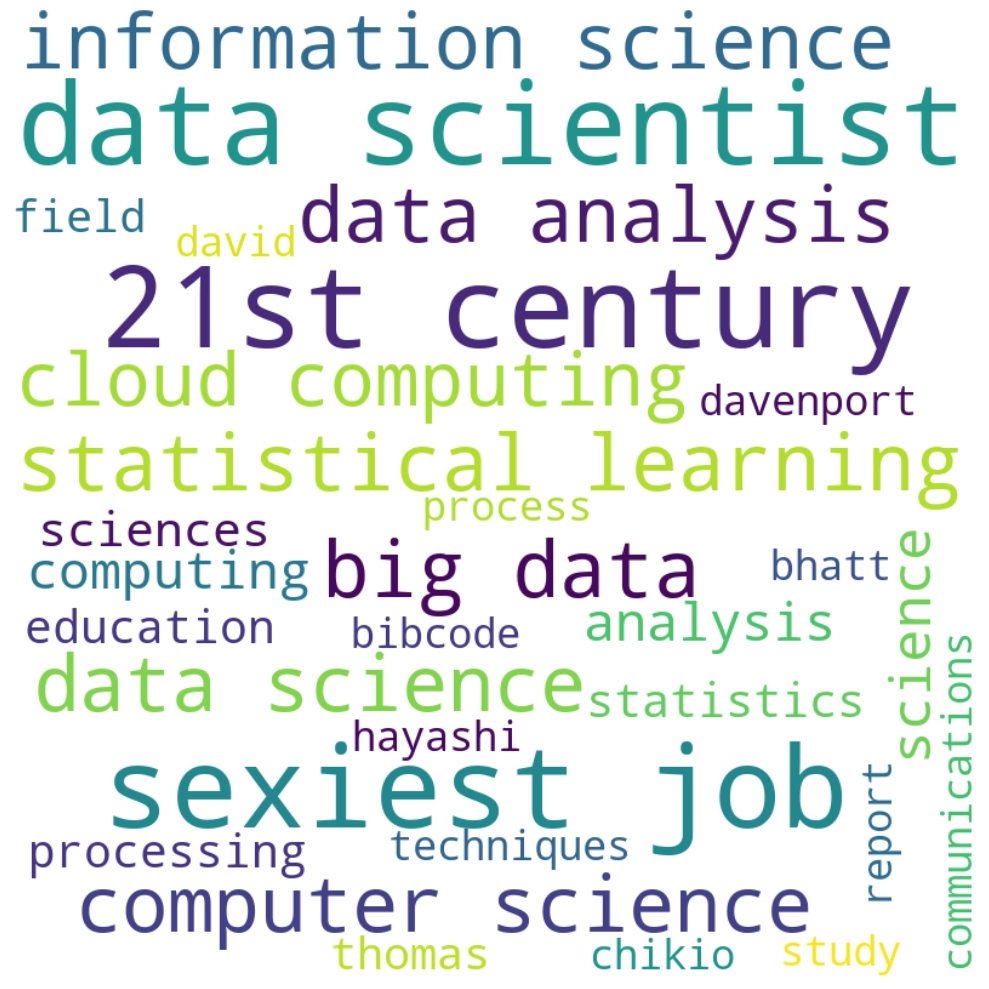

In [101]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
wc = WordCloud(width=800, height=800, background_color="white")
plt.imshow(wc.generate_from_frequencies(dict(results)), interpolation="bilinear") 

plt.axis("off")

plt.tight_layout()
plt.show()